# Week 6：决策树与过拟合

目标：理解决策树如何通过特征阈值切分数据，为什么树太深容易过拟合，以及如何用验证集选择合理复杂度。

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

## 1. 决策树如何学习

决策树反复选择一个特征和阈值，将样本切成更“纯”的子集。例如：

```text
mean radius <= 14.5?
├── 是：继续判断另一个特征
└── 否：继续判断另一个特征
```

二分类中常用 Gini 不纯度衡量一个节点的混杂程度：

$$\mathrm{Gini}=1-(p_0^2+p_1^2)$$

节点只有一种类别时，Gini 为 $0$，表示完全纯净；两类各占一半时，Gini 为 $0.5$，表示最混杂。决策树每次选择能让子节点整体更纯的切分。

In [2]:
dataset = load_breast_cancer(as_frame=True)
X = dataset.data
y = dataset.target

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print('train:', X_train.shape)
print('validation:', X_val.shape)

train: (426, 30)
validation: (143, 30)


## 2. 先训练一棵不限制深度的树

决策树按阈值切分，不依赖特征间的距离或梯度尺度，所以通常不需要像逻辑回归那样先做标准化。

In [3]:
tree_unlimited = DecisionTreeClassifier(random_state=42)
tree_unlimited.fit(X_train, y_train)

train_acc = accuracy_score(y_train, tree_unlimited.predict(X_train))
val_acc = accuracy_score(y_val, tree_unlimited.predict(X_val))

print('tree depth:', tree_unlimited.get_depth())
print('number of leaves:', tree_unlimited.get_n_leaves())
print('train accuracy:', round(train_acc, 3))
print('validation accuracy:', round(val_acc, 3))

tree depth: 7
number of leaves: 18
train accuracy: 1.0
validation accuracy: 0.923


## 3. 用验证集观察树深度与过拟合

`max_depth` 限制树最多向下分裂多少层。树变深时，训练集效果通常不断提高；但验证集效果可能先提高、后下降，这就是过拟合。

   max_depth  train_accuracy  validation_accuracy
0          1           0.923                0.923
1          2           0.958                0.909
2          3           0.977                0.944
3          4           0.988                0.944
4          5           0.995                0.937
5          6           0.998                0.937
6          8           1.000                0.923
7          7           1.000                0.923


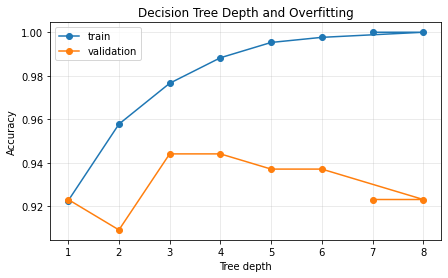

In [4]:
depths = [1, 2, 3, 4, 5, 6, 8, None]
rows = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    rows.append({
        'max_depth': tree.get_depth() if depth is None else depth,
        'train_accuracy': accuracy_score(y_train, tree.predict(X_train)),
        'validation_accuracy': accuracy_score(y_val, tree.predict(X_val)),
    })

depth_results = pd.DataFrame(rows)
print(depth_results.round(3))

plt.figure(figsize=(7, 4))
plt.plot(depth_results['max_depth'], depth_results['train_accuracy'], marker='o', label='train')
plt.plot(depth_results['max_depth'], depth_results['validation_accuracy'], marker='o', label='validation')
plt.xlabel('Tree depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Depth and Overfitting')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 今日检查点

1. 为什么不限制深度的决策树训练集准确率通常很高？
2. 如果训练准确率持续提高、验证准确率下降，说明了什么？
3. 为什么用验证集而不是测试集来选择 `max_depth`？